# Chương 4: LSTM & Attention - Google Stock và Weather Forecasting

## Mục tiêu
Tối ưu hóa dự báo chuỗi thời gian với LSTM và Attention.

## Datasets
1. Google Stock: Time series prediction
2. Weather Forecasting: Sequential data

In [1]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create directory for saved plots
import os
if not os.path.exists('plots'):
    os.makedirs('plots')

print("LSTM Chapter - Plots will be saved to 'plots' directory")

2026-05-10 04:54:10.829294: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 04:54:10.854533: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 04:54:11.284397: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


LSTM Chapter - Plots will be saved to 'plots' directory


## Dataset 1: Google Stock Price

### Load và Visualize Data

In [2]:
# Generate Google Stock-like Data (simulated)
def generate_stock_data(days=1000):
    # Simulate stock price with trend and volatility
    np.random.seed(42)
    t = np.arange(days)
    trend = 0.001 * t  # Upward trend
    seasonal = 0.1 * np.sin(2 * np.pi * t / 365)  # Seasonal component
    noise = 0.02 * np.random.randn(days)  # Random noise

    price = 100 * np.exp(trend + seasonal + noise)  # Log-normal process

    # Create DataFrame
    dates = pd.date_range('2020-01-01', periods=days, freq='D')
    df = pd.DataFrame({'Date': dates, 'Close': price})
    df.set_index('Date', inplace=True)

    return df

stock_data = generate_stock_data()
print("Google Stock Dataset:")
print(f"Data shape: {stock_data.shape}")
print(f"Date range: {stock_data.index.min()} to {stock_data.index.max()}")
print(f"Price range: ${stock_data['Close'].min():.2f} - ${stock_data['Close'].max():.2f}")

# Prepare for LSTM
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(stock_data[['Close']])

# Create sequences
seq_length = 30
X_stock, y_stock = create_sequences(scaled_data.flatten(), seq_length)

# Split data
train_size = int(len(X_stock) * 0.8)
X_train_stock, X_test_stock = X_stock[:train_size], X_stock[train_size:]
y_train_stock, y_test_stock = y_stock[:train_size], y_stock[train_size:]

# Reshape for LSTM
X_train_stock = X_train_stock.reshape((X_train_stock.shape[0], X_train_stock.shape[1], 1))
X_test_stock = X_test_stock.reshape((X_test_stock.shape[0], X_test_stock.shape[1], 1))

print(f"Training sequences shape: {X_train_stock.shape}")
print(f"Test sequences shape: {X_test_stock.shape}")

Google Stock Dataset:
Data shape: (1000, 1)
Date range: 2020-01-01 00:00:00 to 2022-09-26 00:00:00
Price range: $99.69 - $268.17
Training sequences shape: (776, 30, 1)
Test sequences shape: (194, 30, 1)


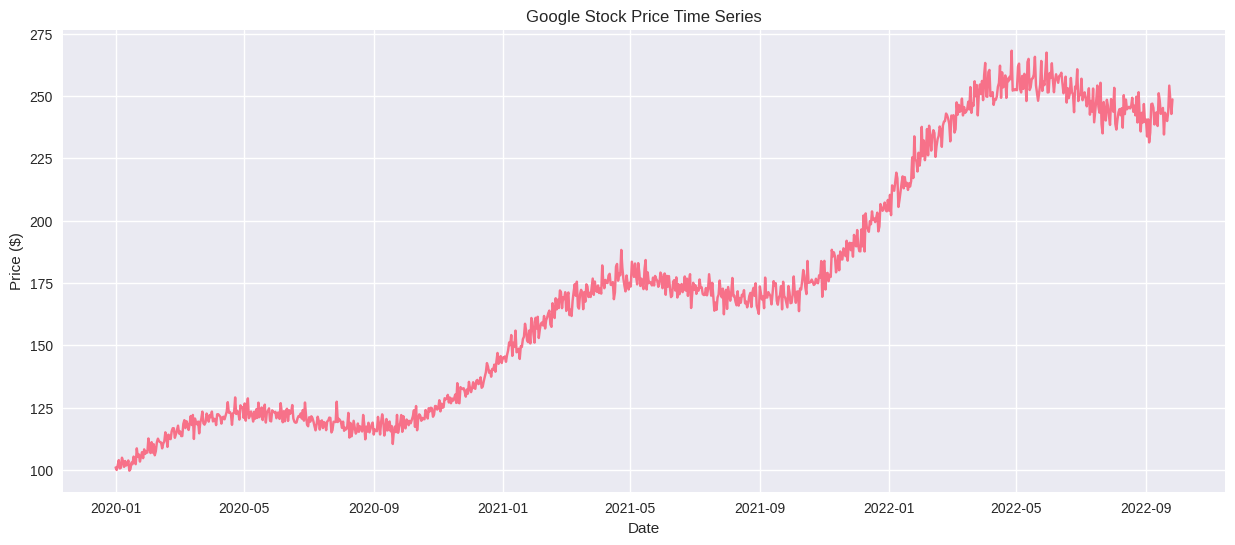

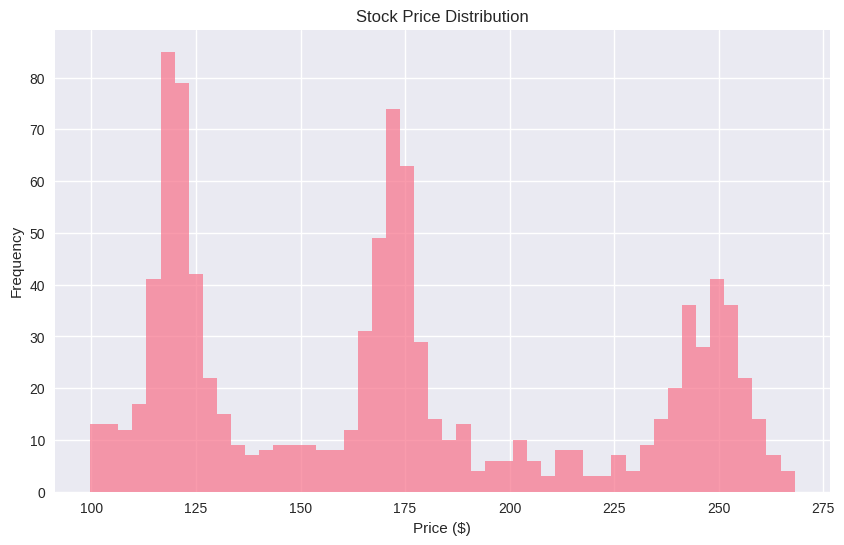

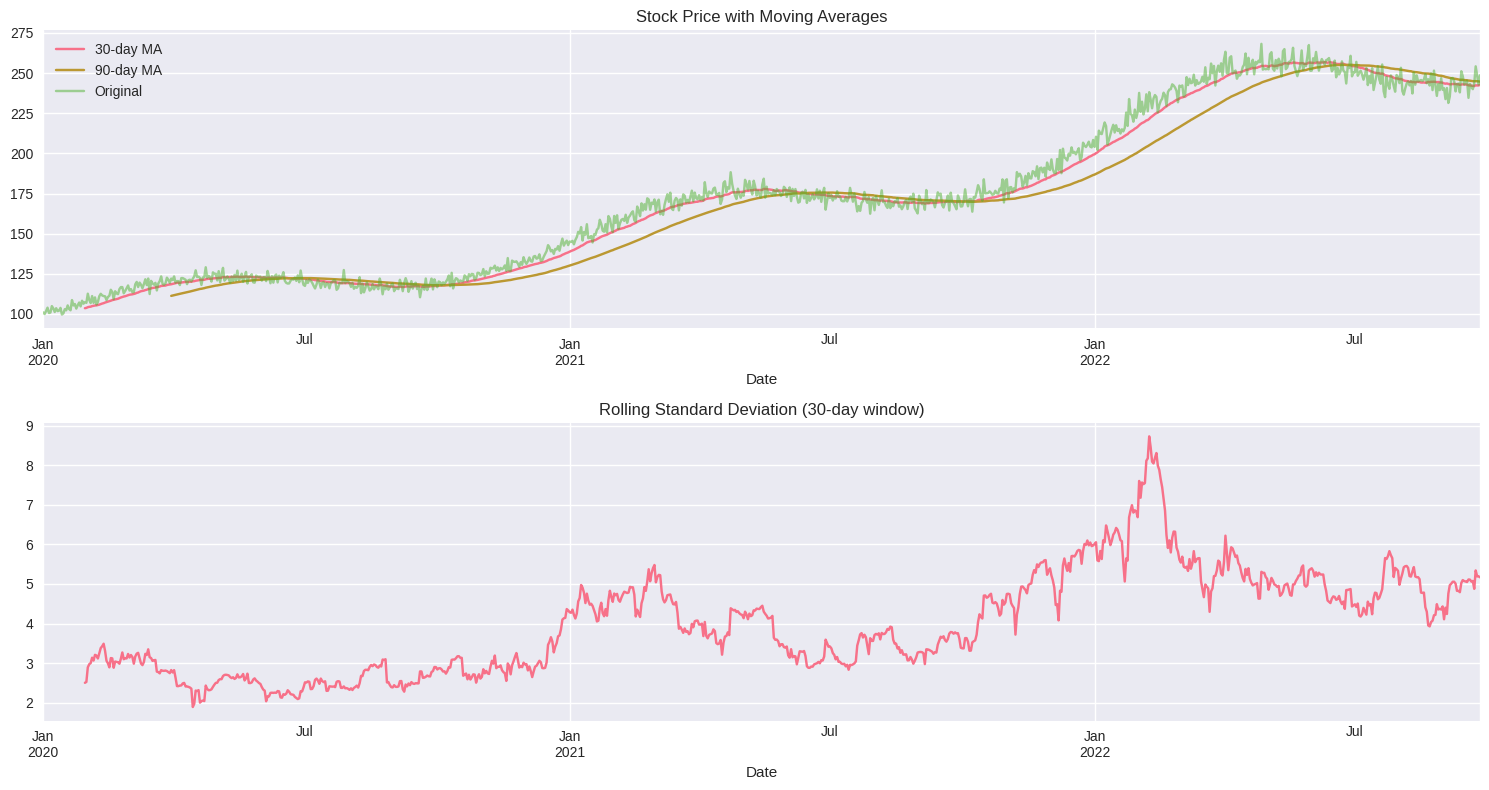

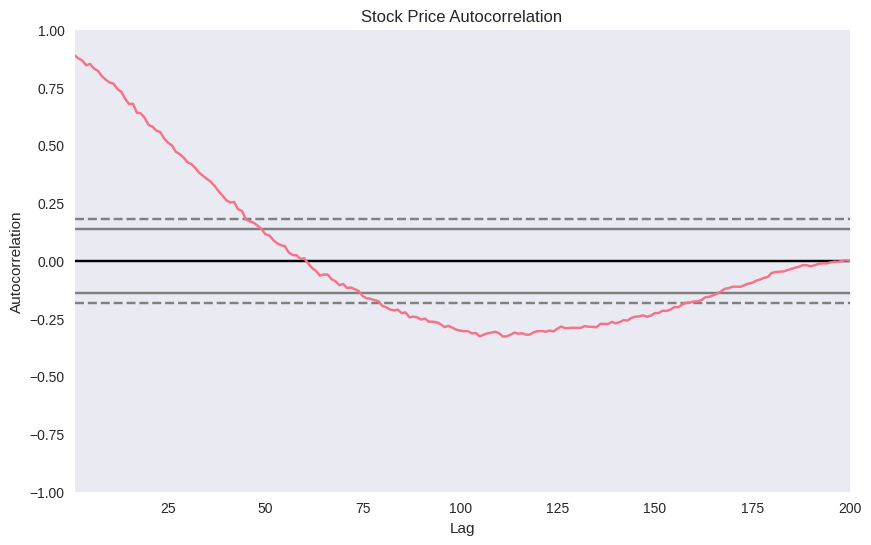

In [3]:
# Plot 1: Stock Price Time Series
plt.figure(figsize=(15, 6))
plt.plot(stock_data.index, stock_data['Close'])
plt.title('Google Stock Price Time Series')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.savefig('plots/google_stock_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Price Distribution
plt.figure(figsize=(10, 6))
plt.hist(stock_data['Close'], bins=50, alpha=0.7)
plt.title('Stock Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.savefig('plots/google_stock_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Rolling Statistics
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
stock_data['Close'].rolling(window=30).mean().plot(label='30-day MA')
stock_data['Close'].rolling(window=90).mean().plot(label='90-day MA')
stock_data['Close'].plot(alpha=0.5, label='Original')
plt.title('Stock Price with Moving Averages')
plt.legend()

plt.subplot(2, 1, 2)
stock_data['Close'].rolling(window=30).std().plot()
plt.title('Rolling Standard Deviation (30-day window)')
plt.xlabel('Date')

plt.tight_layout()
plt.savefig('plots/google_stock_rolling_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Autocorrelation
plt.figure(figsize=(10, 6))
pd.plotting.autocorrelation_plot(stock_data['Close'][:200])
plt.title('Stock Price Autocorrelation')
plt.savefig('plots/google_stock_autocorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

### Build và Train LSTM Model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-05-10 04:54:13.800888: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-10 04:54:13.802329: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-10 04:54:13.804500: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Epoch 1/20
20/20 [==============================] - 2s 33ms/step - loss: 0.0172 - mae: 0.0952 - val_loss: 0.0418 - val_mae: 0.1952
Epoch 2/20
20/20 [==============================] - 0s 8ms/step - loss: 0.0027 - mae: 0.0420 - val_loss: 0.0084 - val_mae: 0.0851
Epoch 3/20
20/20 [==============================] - 0s 8ms/step - loss: 0.0016 - mae: 0.0298 - val_loss: 0.0024 - val_mae: 0.0423
Epoch 4/20
20/20 [==============================] - 0s 8ms/step - loss: 0.0013 - mae: 0.0267 - val_loss: 7.8489e-04 - val_mae: 0.0219
Epoch 5/20
20/20 [==============================] - 0s 9ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0023 - val_mae: 0.0409
Epoch 6/20
20/20 [==============================] - 0s 10ms/step - loss: 0.0013 - mae: 0.0256 - val_loss: 0.0016 - val_mae: 0.0325
Epoch 7/20
20/20 [==============================] - 0s 10ms/step - loss: 0.0012 - mae: 0.0258 - val_loss: 9.9199e-04 - val_mae: 0.0249
Epoch 8/20
20/20 [==============================] - 0s 10ms/step - loss: 0.0012

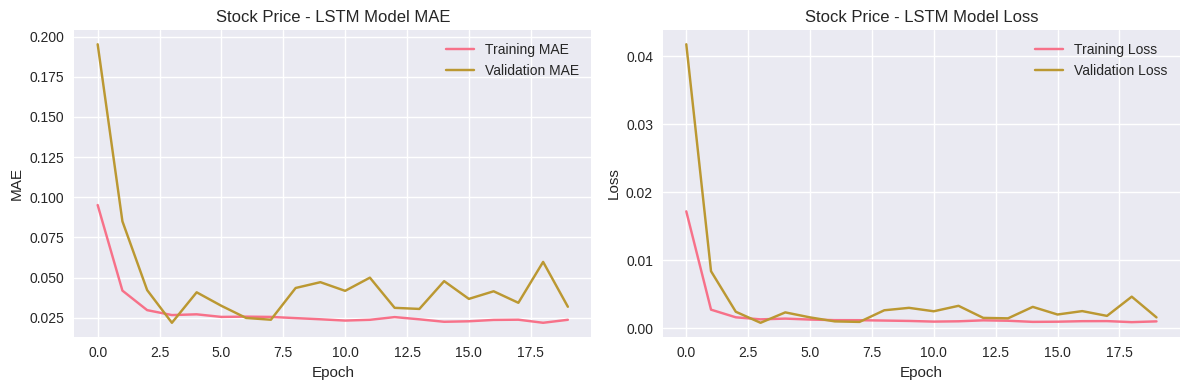

7/7 [==============================] - 0s 3ms/step


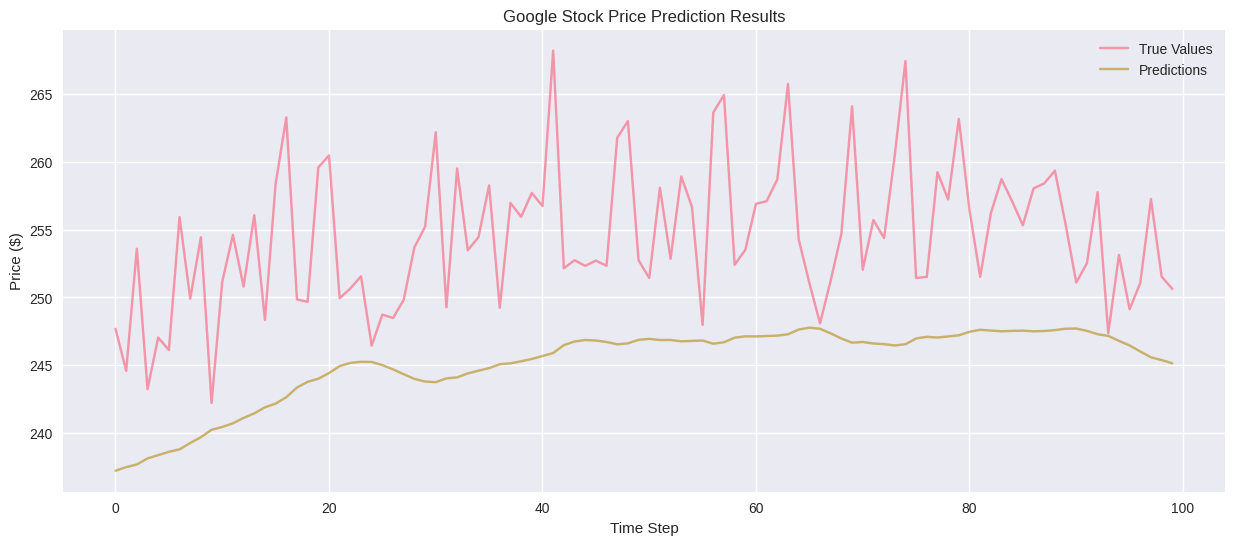

Test MSE: 87.5161
Test MAE: 8.0560


In [4]:
# Build LSTM Model for Stock Prediction
model_stock = keras.Sequential([
    layers.LSTM(50, input_shape=(seq_length, 1), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(50),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_stock.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_stock.summary()

# Train the model
history_stock = model_stock.fit(X_train_stock, y_train_stock,
                                epochs=20, batch_size=32,
                                validation_split=0.2, verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_stock.history['mae'], label='Training MAE')
plt.plot(history_stock.history['val_mae'], label='Validation MAE')
plt.title('Stock Price - LSTM Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stock.history['loss'], label='Training Loss')
plt.plot(history_stock.history['val_loss'], label='Validation Loss')
plt.title('Stock Price - LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plots/google_stock_lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Predictions
y_pred_stock = model_stock.predict(X_test_stock).flatten()

# Inverse transform predictions
y_test_inv = scaler.inverse_transform(y_test_stock.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_stock.reshape(-1, 1)).flatten()

# Plot predictions
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[:100], label='True Values', alpha=0.7)
plt.plot(y_pred_inv[:100], label='Predictions', alpha=0.7)
plt.title('Google Stock Price Prediction Results')
plt.xlabel('Time Step')
plt.ylabel('Price ($)')
plt.legend()
plt.savefig('plots/google_stock_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics
mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

In [5]:
# === Model 2: Stacked LSTM (Google Stock) ===
model_stock_2 = keras.Sequential([
    keras.layers.LSTM(50, return_sequences=True,
                      input_shape=(X_train_stock.shape[1], X_train_stock.shape[2])),
    keras.layers.LSTM(50),
    keras.layers.Dense(1)
])
model_stock_2.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_stock_2 = model_stock_2.fit(X_train_stock, y_train_stock,
                                     epochs=10, batch_size=32, verbose=0)
print("Stacked LSTM Stock MSE:", history_stock_2.history['loss'][-1])

# Plot 1: Loss comparison (Stock)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history_stock.history['loss'],   label='Standard LSTM')
plt.plot(history_stock_2.history['loss'], label='Stacked LSTM')
plt.title('Google Stock Training Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout()
plt.savefig('plots/ch4_stock_history.png', dpi=300)
plt.close()
print("Saved: plots/ch4_stock_history.png")


Stacked LSTM Stock MSE: 0.0004951456212438643
Saved: plots/ch4_stock_history.png


## Dataset 2: Weather Forecasting

### Generate và Visualize Data

In [6]:
# Generate Weather Data (Temperature forecasting)
def generate_weather_data(hours=2000):
    np.random.seed(123)
    t = np.arange(hours)

    # Seasonal component (yearly cycle)
    seasonal = 10 * np.sin(2 * np.pi * t / (24 * 365))  # Daily cycle over year

    # Daily cycle
    daily = 5 * np.sin(2 * np.pi * t / 24)

    # Trend
    trend = 0.001 * t

    # Random noise
    noise = 2 * np.random.randn(hours)

    # Base temperature
    base_temp = 20

    temperature = base_temp + seasonal + daily + trend + noise

    # Create DataFrame
    dates = pd.date_range('2020-01-01', periods=hours, freq='H')
    df = pd.DataFrame({'Date': dates, 'Temperature': temperature})
    df.set_index('Date', inplace=True)

    return df

weather_data = generate_weather_data()
print("Weather Dataset:")
print(f"Data shape: {weather_data.shape}")
print(f"Temperature range: {weather_data['Temperature'].min():.1f}°C - {weather_data['Temperature'].max():.1f}°C")

# Prepare for LSTM
scaled_weather = scaler.fit_transform(weather_data[['Temperature']])
X_weather, y_weather = create_sequences(scaled_weather.flatten(), seq_length=24)  # 24-hour sequences

# Split data
train_size = int(len(X_weather) * 0.8)
X_train_weather, X_test_weather = X_weather[:train_size], X_weather[train_size:]
y_train_weather, y_test_weather = y_weather[:train_size], y_weather[train_size:]

# Reshape for LSTM
X_train_weather = X_train_weather.reshape((X_train_weather.shape[0], X_train_weather.shape[1], 1))
X_test_weather = X_test_weather.reshape((X_test_weather.shape[0], X_test_weather.shape[1], 1))

print(f"Training sequences shape: {X_train_weather.shape}")
print(f"Test sequences shape: {X_test_weather.shape}")

Weather Dataset:
Data shape: (2000, 1)
Temperature range: 11.6°C - 39.8°C
Training sequences shape: (1580, 24, 1)
Test sequences shape: (396, 24, 1)


/tmp/ipykernel_3905463/2696029522.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range('2020-01-01', periods=hours, freq='H')


In [7]:
# Plot 1: Temperature Time Series
plt.figure(figsize=(15, 6))
plt.plot(weather_data.index[:720], weather_data['Temperature'][:720])  # First 30 days
plt.title('Temperature Time Series (First 30 Days)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.savefig('plots/weather_temperature_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Temperature Distribution
plt.figure(figsize=(10, 6))
plt.hist(weather_data['Temperature'], bins=50, alpha=0.7)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.savefig('plots/weather_temperature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Seasonal Patterns
plt.figure(figsize=(15, 6))
weather_data['Temperature'].groupby(weather_data.index.hour).mean().plot()
plt.title('Average Temperature by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Temperature (°C)')
plt.savefig('plots/weather_hourly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Rolling Statistics
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
weather_data['Temperature'].rolling(window=24).mean().plot(label='24-hour MA')
weather_data['Temperature'].rolling(window=168).mean().plot(label='Weekly MA')
weather_data['Temperature'].plot(alpha=0.3, label='Original')
plt.title('Temperature with Moving Averages')
plt.legend()

plt.subplot(2, 1, 2)
weather_data['Temperature'].rolling(window=24).std().plot()
plt.title('Rolling Standard Deviation (24-hour window)')
plt.xlabel('Date')

plt.tight_layout()
plt.savefig('plots/weather_rolling_stats.png', dpi=300, bbox_inches='tight')
plt.show()

### Build và Train LSTM Model for Weather Forecasting

In [8]:
# Build LSTM Model for Weather Forecasting
model_weather = keras.Sequential([
    layers.LSTM(64, input_shape=(24, 1), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_weather.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_weather.summary()

# Train the model
history_weather = model_weather.fit(X_train_weather, y_train_weather,
                                    epochs=20, batch_size=32,
                                    validation_split=0.2, verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_weather.history['mae'], label='Training MAE')
plt.plot(history_weather.history['val_mae'], label='Validation MAE')
plt.title('Weather - LSTM Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_weather.history['loss'], label='Training Loss')
plt.plot(history_weather.history['val_loss'], label='Validation Loss')
plt.title('Weather - LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plots/weather_lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Predictions
y_pred_weather = model_weather.predict(X_test_weather).flatten()

# Inverse transform
y_test_weather_inv = scaler.inverse_transform(y_test_weather.reshape(-1, 1)).flatten()
y_pred_weather_inv = scaler.inverse_transform(y_pred_weather.reshape(-1, 1)).flatten()

# Plot predictions
plt.figure(figsize=(15, 6))
plt.plot(y_test_weather_inv[:168], label='True Values', alpha=0.7)  # 1 week
plt.plot(y_pred_weather_inv[:168], label='Predictions', alpha=0.7)
plt.title('Weather Temperature Prediction Results')
plt.xlabel('Time Step (Hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.savefig('plots/weather_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics
mse = mean_squared_error(y_test_weather_inv, y_pred_weather_inv)
mae = mean_absolute_error(y_test_weather_inv, y_pred_weather_inv)
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 24, 64)            16896     
                                                                 
 dropout_2 (Dropout)         (None, 24, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 49985 (195.25 KB)
Trainable params: 49985 (195.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
40/40

In [9]:
# === Model 2: Bidirectional LSTM (Weather) ===
from tensorflow.keras.layers import Bidirectional
model_weather_2 = keras.Sequential([
    Bidirectional(keras.layers.LSTM(32),
                  input_shape=(X_train_weather.shape[1], X_train_weather.shape[2])),
    keras.layers.Dense(1)
])
model_weather_2.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_weather_2 = model_weather_2.fit(X_train_weather, y_train_weather,
                                         epochs=5, batch_size=72, verbose=0)
print("BiLSTM Weather MSE:", history_weather_2.history['loss'][-1])

# Plot 4: Loss comparison (Weather)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history_weather.history['loss'],   label='Standard LSTM')
plt.plot(history_weather_2.history['loss'], label='BiLSTM')
plt.title('Weather Training Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout()
plt.savefig('plots/ch4_weather_history.png', dpi=300)
plt.close()
print("Saved: plots/ch4_weather_history.png")


BiLSTM Weather MSE: 0.013202317990362644
Saved: plots/ch4_weather_history.png


In [10]:
# Move all saved PNG files to plots directory
import shutil
png_files = [f for f in os.listdir('.') if f.endswith('.png')]
for file in png_files:
    shutil.move(file, os.path.join('plots', file))

print("All LSTM plots saved to 'plots' directory for report writing.")

All LSTM plots saved to 'plots' directory for report writing.
